# **USV-DETR demo**

Welcome, and thanks for trying USV-DETR. This notebook runs the full pipeline end to end: audio in, a table of detected calls and figures out.

Before you start, prepare an ultrasonic WAV file of your own. The example here uses a rat USV recording sampled at 250 kHz, saved as `test.wav`.

This notebook needs a GPU. Go to **Runtime > Change runtime type**, select any available GPU as the hardware accelerator, and save before running anything below.

In [ ]:
# ============================================================
# Step 1: Set up the environment
#   - verify that a GPU is attached
#   - clone the upstream RT-DETRv4 codebase, which holds the model definition
#   - install upstream dependencies, skipping the ones Colab already has
#   - install the usvdetr package from GitHub
# ============================================================

import os
import sys
import subprocess

# ---------------- editable parameters ----------------
UPSTREAM_URL = "https://github.com/RT-DETRs/RT-DETRv4.git"
UPSTREAM_DIR = "/content/RT-DETRv4"
USVDETR_URL = "git+https://github.com/weiyilan9/USV-DETR.git"
SKIP_PACKAGES = ("torch", "torchvision", "torchaudio")
# -----------------------------------------------------

import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. Set Runtime > Change runtime type > T4 GPU, "
        "then run this cell again."
    )
print("GPU:", torch.cuda.get_device_name(0))
print("torch:", torch.__version__)

# Clone the upstream codebase if it is not there yet.
if not os.path.isdir(os.path.join(UPSTREAM_DIR, "engine")):
    subprocess.run(
        ["git", "clone", "--depth", "1", UPSTREAM_URL, UPSTREAM_DIR],
        check=True,
    )
print("upstream:", UPSTREAM_DIR)

# Reinstalling torch would replace the CUDA build Colab ships with, so the
# upstream requirements are filtered before installing.
source = os.path.join(UPSTREAM_DIR, "requirements.txt")
filtered = os.path.join(UPSTREAM_DIR, "requirements_inference.txt")

keep = []
with open(source, "r", encoding="utf-8") as handle:
    for line in handle:
        item = line.strip()
        if not item or item.startswith("#"):
            continue
        if item.lower().startswith(SKIP_PACKAGES):
            continue
        keep.append(item)

with open(filtered, "w", encoding="utf-8") as handle:
    handle.write("\n".join(keep) + "\n")
print("upstream requirements kept:", len(keep))

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", filtered], check=True
)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", USVDETR_URL], check=True
)

# The upstream package is imported as "engine", so its root must be on the path.
if UPSTREAM_DIR not in sys.path:
    sys.path.insert(0, UPSTREAM_DIR)

import usvdetr
print("usvdetr:", usvdetr.__version__)

GPU: NVIDIA A100-SXM4-40GB
torch: 2.11.0+cu128
upstream: /content/RT-DETRv4
upstream requirements kept: 6
usvdetr: 0.1.0


## **Model weights**

The trained model is hosted on Hugging Face and downloads automatically.

In [ ]:
# ============================================================
# Step 2: Download the checkpoint and put the config where it can resolve
#   - pull USV-DETR.pth and USV-DETR.yml from Hugging Face
#   - copy the config into the upstream configs tree, one level down, so its
#     relative include paths point at real files
# ============================================================

import os
import shutil

import yaml
from huggingface_hub import hf_hub_download

# ---------------- editable parameters ----------------
HF_REPO = "yilanwei/USV-DETR"
CHECKPOINT_NAME = "USV-DETR.pth"
CONFIG_NAME = "USV-DETR.yml"
CONFIG_SUBDIR = "configs/usvdetr"
# -----------------------------------------------------

CHECKPOINT_PATH = hf_hub_download(HF_REPO, CHECKPOINT_NAME)
cached_config = hf_hub_download(HF_REPO, CONFIG_NAME)

config_dir = os.path.join(UPSTREAM_DIR, CONFIG_SUBDIR)
os.makedirs(config_dir, exist_ok=True)

CONFIG_PATH = os.path.join(config_dir, CONFIG_NAME)
shutil.copy(cached_config, CONFIG_PATH)

print("checkpoint:", CHECKPOINT_PATH)
print("config:    ", CONFIG_PATH)

# The config refers to other config files by relative path, so check that each
# one resolves from where the config now sits.
with open(CONFIG_PATH, "r", encoding="utf-8") as handle:
    includes = yaml.safe_load(handle).get("__include__", [])

if isinstance(includes, str):
    includes = [includes]

for item in includes:
    target = os.path.normpath(os.path.join(config_dir, item))
    print("include %-42s %s" % (item, "ok" if os.path.exists(target) else "MISSING"))

USV-DETR.pth: reconstructing file:   0%|          |  0.00B /  566MB            

USV-DETR.pth: downloading bytes:           |  0.00B            

USV-DETR.yml:   0%|          | 0.00/2.31k [00:00<?, ?B/s]

checkpoint: /root/.cache/huggingface/hub/models--yilanwei--USV-DETR/snapshots/9e3754389b965c9b233895c4065b880f09ac8f35/USV-DETR.pth
config:     /content/RT-DETRv4/configs/usvdetr/USV-DETR.yml
include ../dfine/dfine_hgnetv2_l_coco.yml          ok
include ../base/deim.yml                           ok


## **Load the model**

This builds the network and loads the trained weights onto the GPU, then runs a
blank image through it to check that everything works.


In [ ]:
# ============================================================
# Step 3: Load the trained model and check that it runs
#   - build the network from the config and load the checkpoint
#   - move everything to the GPU
#   - run one blank image through to confirm the output shapes
# ============================================================

import torch

from usvdetr import load_model

# ---------------- editable parameters ----------------
DEVICE = None      # None picks the GPU when one is available
INPUT_SIZE = 640   # square side the model expects
# -----------------------------------------------------

model, device = load_model(CONFIG_PATH, CHECKPOINT_PATH, DEVICE, verbose=False)
print("model loaded on", device)

with torch.no_grad():
    outputs = model(torch.zeros(1, 3, INPUT_SIZE, INPUT_SIZE, device=device))

for name, value in outputs.items():
    if torch.is_tensor(value):
        print("%-12s %s" % (name, tuple(value.shape)))

model loaded on cuda
pred_logits  (1, 300, 1)
pred_boxes   (1, 300, 4)


## **Look at the spectrograms**

Upload your wav file first. Click the folder icon in the left sidebar, then the
upload button, and pick your file. The cell below expects it at
`/content/test.wav`.

Nothing is detected yet. This step just shows what the model will see, so you
can check that the calls are visible and sit inside the frequency band. If they
look washed out or too dark, adjust `GAMMA` and rerun.

duration: 10.0 s, sample rate: 250000 Hz


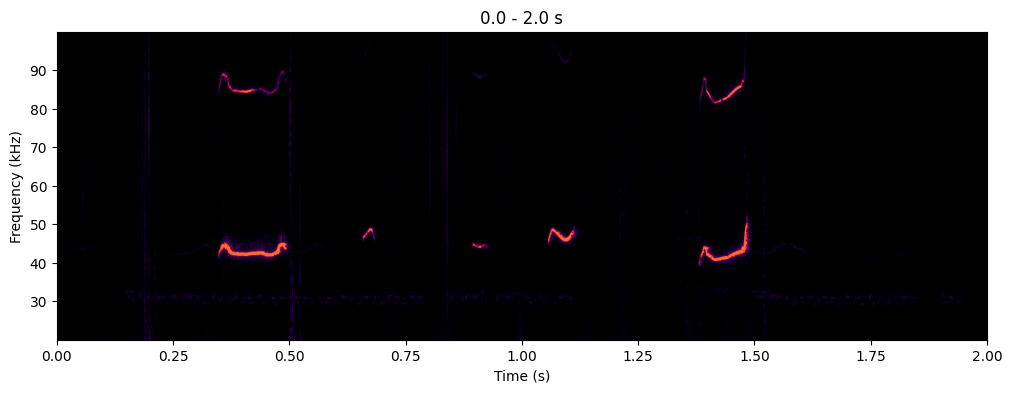

In [ ]:
# ============================================================
# Step 4: Turn the audio into spectrogram images
#   - load the wav file and report its length
#   - cut a preview range into fixed-length windows
#   - render each window the way the model will see it
# ============================================================

import matplotlib.pyplot as plt

from usvdetr import (
    load_audio,
    slice_audio,
    iter_segments,
    make_spectrogram,
    spectrogram_to_rgb,
)

# ---------------- editable parameters ----------------
WAV_PATH = "/content/test.wav"
SAMPLE_RATE = 250000       # expected rate, set to None to accept any

PREVIEW_START_SEC = 0.0    # start of the range to preview
PREVIEW_END_SEC = 2.0      # end of the range to preview

WINDOW_SEC = 2.0           # duration of one spectrogram image
STEP_SEC = 2.0             # hop between images, equal means no overlap

LOW_FREQ_HZ = 20000        # bottom of the frequency band
HIGH_FREQ_HZ = 100000      # top of the frequency band
GAMMA = 2.0                # contrast, higher darkens the background

FIGSIZE = (12, 4)
# -----------------------------------------------------

audio, sample_rate = load_audio(WAV_PATH, SAMPLE_RATE)
print("duration: %.1f s, sample rate: %d Hz" % (len(audio) / sample_rate, sample_rate))

preview = slice_audio(audio, sample_rate, PREVIEW_START_SEC, PREVIEW_END_SEC)

segments = iter_segments(
    preview, sample_rate, WINDOW_SEC, STEP_SEC,
    time_offset_sec=PREVIEW_START_SEC,
)

for start_sec, end_sec, segment in segments:
    freqs_hz, _, power = make_spectrogram(
        segment, sample_rate,
        low_freq_hz=LOW_FREQ_HZ,
        high_freq_hz=HIGH_FREQ_HZ,
        gamma=GAMMA,
    )
    rgb = spectrogram_to_rgb(power)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.imshow(
        rgb, origin="lower", aspect="auto",
        extent=[start_sec, end_sec, freqs_hz[0] / 1000, freqs_hz[-1] / 1000],
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (kHz)")
    ax.set_title("%.1f - %.1f s" % (start_sec, end_sec))
    plt.show()

## **Detect calls in a few windows**

Same windows as before, now with the model running on each one. Boxes are drawn
over the calls it found, labelled `USV` or `Harmonic`.

`CONF_THRESHOLD` is the main dial. Lower it if calls are being missed, raise it
if noise is being picked up. Check a few windows before running the whole file.

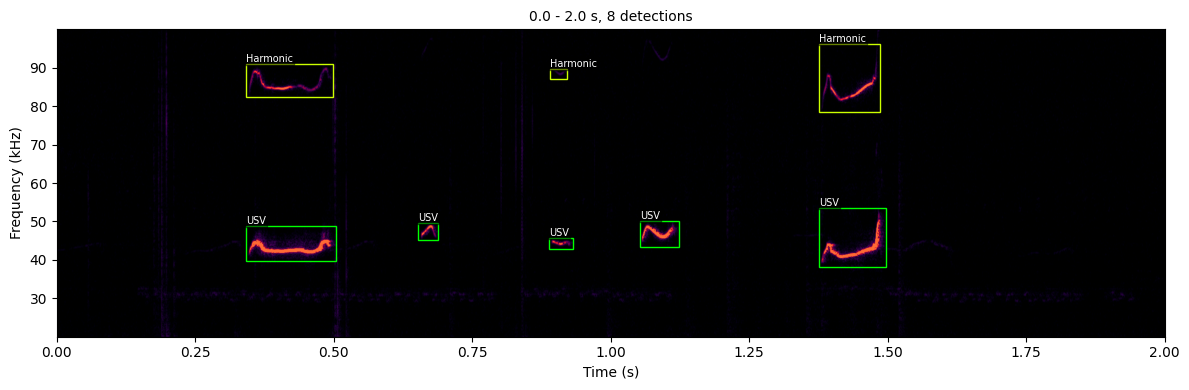

In [ ]:
# ============================================================
# Step 5: Run detection on a preview range and draw the boxes
#   - render each window as before
#   - run the model on it
#   - draw the detected calls over the spectrogram
# ============================================================

from usvdetr import predict_on_rgb_image, show_prediction

# ---------------- editable parameters ----------------
CONF_THRESHOLD = 0.6        # minimum detection score to keep
NMS_IOU = 0.4               # merges heavily overlapping boxes

CONTAINMENT_THRESH = 0.7    # drops a box mostly swallowed by a larger one
TIME_OVERLAP_THRESH = 0.7   # time overlap needed to call something a harmonic
RATIO_MIN = 1.8             # lowest accepted harmonic frequency ratio
RATIO_MAX = 2.2             # highest accepted harmonic frequency ratio

SHOW_SCORES = False         # print the confidence next to each label
# -----------------------------------------------------

segments = iter_segments(
    preview, sample_rate, WINDOW_SEC, STEP_SEC,
    time_offset_sec=PREVIEW_START_SEC,
)

for start_sec, end_sec, segment in segments:
    freqs_hz, _, power = make_spectrogram(
        segment, sample_rate,
        low_freq_hz=LOW_FREQ_HZ,
        high_freq_hz=HIGH_FREQ_HZ,
        gamma=GAMMA,
    )
    rgb = spectrogram_to_rgb(power)

    result = predict_on_rgb_image(
        model, device, rgb,
        start_sec, end_sec,
        freqs_hz[0] / 1000, freqs_hz[-1] / 1000,
        conf_threshold=CONF_THRESHOLD,
        nms_iou=NMS_IOU,
    )

    show_prediction(
        result,
        title="%.1f - %.1f s, %d detections" % (start_sec, end_sec, len(result["boxes"])),
        containment_thresh=CONTAINMENT_THRESH,
        time_overlap_thresh=TIME_OVERLAP_THRESH,
        ratio_min=RATIO_MIN,
        ratio_max=RATIO_MAX,
        show_scores=SHOW_SCORES,
        figsize=FIGSIZE,
    )

## **Run the whole file and export the results**

This processes the full recording and writes a table with one row per detected
call. The settings from the previous steps are reused, so whatever looked right
on the preview windows is what runs here.

Long recordings take proportionally longer, and `PROGRESS_EVERY` prints a line as it goes so you can see it moving.

In [ ]:
# ============================================================
# Step 6: Detect calls across the whole file and save the table
#   - run the detector window by window over the full recording
#   - write the results to an xlsx file
#   - print a short summary
#
# How the Harmonic label is decided:
#   The model itself does not distinguish harmonics. It detects one class,
#   and the label is worked out afterwards from the geometry of the boxes.
#   A detection is labelled Harmonic only when another detection
#     1. overlaps it in time by at least TIME_OVERLAP_THRESH, measured as a
#        fraction of the shorter of the two boxes, and
#     2. sits at a lower mean frequency, with a ratio between RATIO_MIN and
#        RATIO_MAX, so roughly half the frequency.
#   Boxes are visited from high frequency to low, and each fundamental can be
#   claimed by only one harmonic, so a stack of overlapping calls does not
#   collapse into a single chain. When several candidates qualify, the one
#   with a ratio closest to exactly 2.0 wins.
#
# What pair_id means:
#   The id shared by a harmonic and the fundamental it was matched to. The two
#   rows carry the same number, which is unique across the whole file. Rows
#   left blank are calls with no harmonic partner. Dividing the count of
#   non-blank pair_id values by two gives the number of pairs.
# ============================================================

from usvdetr import detect_wav, save_records

# ---------------- editable parameters ----------------
OUTPUT_PATH = "/content/detections.xlsx"   # use .csv for a plain text table
PROGRESS_EVERY = 50                        # print a line every N windows, 0 for silence
PREVIEW_ROWS = 5                           # rows to print after saving
# -----------------------------------------------------

df = detect_wav(
    model, device, WAV_PATH,
    expected_sample_rate=SAMPLE_RATE,
    window_sec=WINDOW_SEC,
    step_sec=STEP_SEC,
    low_freq_hz=LOW_FREQ_HZ,
    high_freq_hz=HIGH_FREQ_HZ,
    conf_threshold=CONF_THRESHOLD,
    nms_iou=NMS_IOU,
    containment_thresh=CONTAINMENT_THRESH,
    time_overlap_thresh=TIME_OVERLAP_THRESH,
    ratio_min=RATIO_MIN,
    ratio_max=RATIO_MAX,
    spectrogram_kwargs={"gamma": GAMMA},
    progress_every=PROGRESS_EVERY,
)

df_out = save_records(df, OUTPUT_PATH, preview_rows=PREVIEW_ROWS)

# Each pair contributes two rows, one harmonic and one fundamental.
print()
print("calls: %d, harmonics: %d, pairs: %d" % (
    (df["label"] == "USV").sum(),
    (df["label"] == "Harmonic").sum(),
    df["pair_id"].notna().sum() // 2,
))

test.wav | 10.0s | USV 31 | Harmonic 23
saved: /content/detections.xlsx (54 rows)
filename  audio_duration_s  seg_start_s  seg_end_s  onset_time_s  offset_time_s  duration_ms  freq_min_khz  freq_max_khz  freq_mean_khz  freq_bandwidth_khz    label  pair_id  confidence
test.wav              10.0          0.0        2.0        0.3409         0.4978       156.93         82.33         90.98          86.65                8.66 Harmonic      0.0      0.8408
test.wav              10.0          0.0        2.0        0.3414         0.5042       162.79         39.67         48.81          44.24                9.14      USV      0.0      0.8350
test.wav              10.0          0.0        2.0        0.6520         0.6886        36.58         45.07         49.68          47.37                4.61      USV      NaN      0.7883
test.wav              10.0          0.0        2.0        0.8886         0.9326        44.03         42.83         45.69          44.26                2.86      USV      2.0 

## **Plot the results**

The table you just exported is plain tabular data, so you can plot it however
your own analysis needs.

Here is one example. Say you want to see when calls occur across the whole
recording, and how they group together over time. The two figures below do that:
one line per call at its mean frequency, and the same calls merged into bouts
with the silence between them marked.

No model is perfect, and this one is no exception. Recording setups, species and
age ranges vary, so some tuning is usually needed before the output fits a given
dataset. Suggestions and improvements are welcome on the GitHub issue tracker,
and sharing them is useful to others working on USVs.

Treat this as a starting point and change it freely. Enjoy.

10.0 s of audio, figure width 12.0 in
saved figure: /content/timeline.png


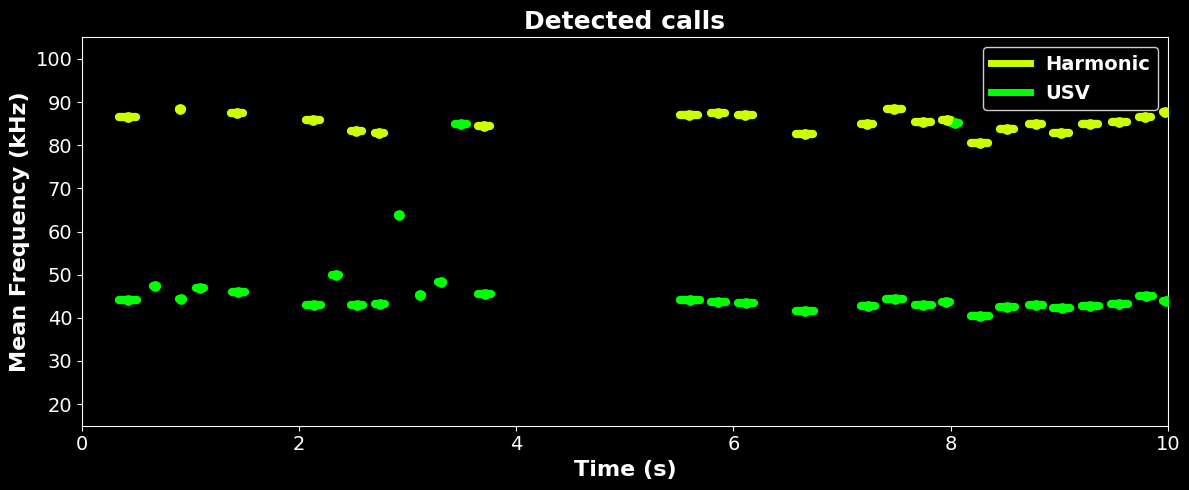

USV bouts: 2, Harmonic bouts: 2
saved figure: /content/bouts.png


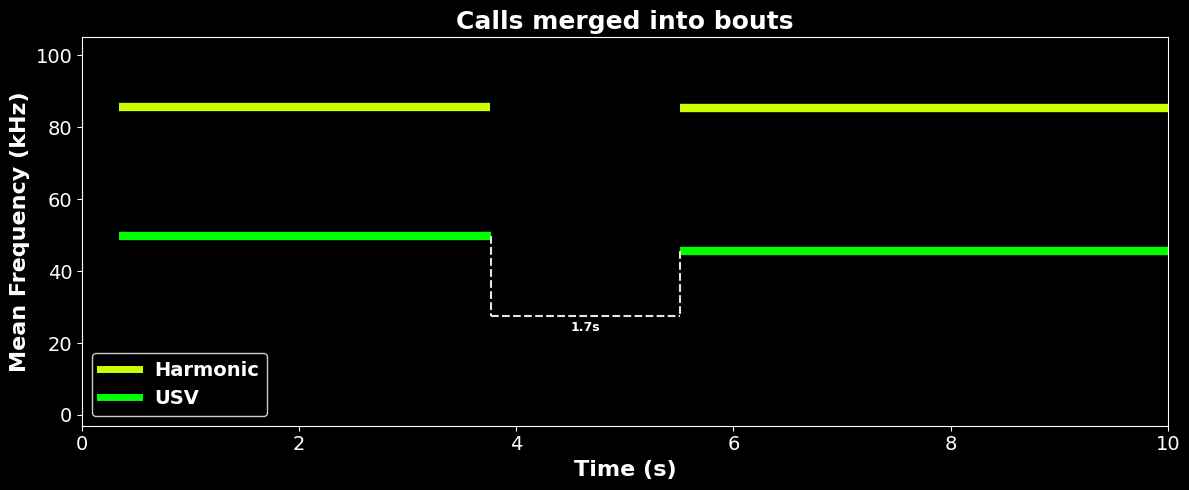

In [ ]:
# ============================================================
# Step 7: Plot the detections over time
#   - one line per detected call, at its mean frequency
#   - the same calls merged into bouts, with the gaps annotated
#   - both figures saved at print resolution
#
# What a bout is:
#   Consecutive calls of the same label separated by less than GAP_THRESH_SEC
#   of silence are grouped into one bout. The bout is drawn at the mean
#   frequency of its member calls, and the dashed brackets below the lines
#   give the silent interval between neighbouring USV bouts in seconds.
# ============================================================

from usvdetr import plot_detection_timeline, plot_bout_timeline

# ---------------- editable parameters ----------------
GAP_THRESH_SEC = 1.0        # silence longer than this starts a new bout

TIMELINE_PATH = "/content/timeline.png"
BOUT_PATH = "/content/bouts.png"
DPI = 300

WIDTH_PER_SECOND = 0.4      # figure inches per second of audio
MIN_WIDTH = 12              # keep short files from coming out cramped
MAX_WIDTH = 60              # keep long files from producing huge images
FIGURE_HEIGHT = 5

SHOW_DOTS = True            # mark the centre of each call
SHOW_INTERVALS = True       # annotate the gaps between bouts
# -----------------------------------------------------

duration_sec = float(df["audio_duration_s"].iloc[0])

# Scale the width with the recording length, so a two minute file is not
# squeezed into the same figure as a thirty second one.
width = min(MAX_WIDTH, max(MIN_WIDTH, duration_sec * WIDTH_PER_SECOND))
timeline_figsize = (width, FIGURE_HEIGHT)
print("%.1f s of audio, figure width %.1f in" % (duration_sec, width))

# Both functions return the figure and axes so you can keep editing them.
# Assigning to _ stops the notebook from echoing that pair below the plot.
_ = plot_detection_timeline(
    df, duration_sec,
    freq_min_khz=LOW_FREQ_HZ / 1000,
    freq_max_khz=HIGH_FREQ_HZ / 1000,
    title="Detected calls",
    figsize=timeline_figsize,
    show_dots=SHOW_DOTS,
    save_path=TIMELINE_PATH,
    dpi=DPI,
)

_ = plot_bout_timeline(
    df, duration_sec,
    freq_min_khz=LOW_FREQ_HZ / 1000,
    freq_max_khz=HIGH_FREQ_HZ / 1000,
    gap_thresh_sec=GAP_THRESH_SEC,
    title="Calls merged into bouts",
    figsize=timeline_figsize,
    show_intervals=SHOW_INTERVALS,
    save_path=BOUT_PATH,
    dpi=DPI,
)